### Data Science 파이썬 데이터 처리 과제

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

#### 1. Titanic에서 데이터 수집

In [ ]:
df = pd.read_csv("titanic.csv")
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("=== 결측치 현황 (전처리 전) ===")
df.isnull().sum()

=== 결측치 현황 (전처리 전) ===


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### 2. 결측치 처리

-> age, embarked, cabin

In [ ]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

print("=== 결측치 현황 (전처리 후) ===")
df[['Age', 'Embarked', 'Has_Cabin']].isnull().sum()

=== 결측치 현황 (전처리 후) ===


Age          0
Embarked     0
Has_Cabin    0
dtype: int64

#### 3. 그룹 요약

In [ ]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("성별 생존율")
survival_by_sex

성별 생존율


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [ ]:
survival_by_pclass = df.groupby('Pclass')['Survived'].agg(['mean', 'count'])
print("좌석 등급별 생존율 및 인원수")
survival_by_pclass

좌석 등급별 생존율 및 인원수


,mean,count
Pclass,,
1,0.629630,216
2,0.472826,184
3,0.242363,491


In [ ]:
survival_by_embarked = df.groupby('Embarked')['Survived'].mean()
print("승선 항구별 생존율")
survival_by_embarked

승선 항구별 생존율


Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

#### 4. Pivot Table 분석
행 = Sex, 열 = Pclass, 값 = Survived 평균

In [ ]:
pivot_sex_pclass = pd.pivot_table(
    df, index='Sex', columns='Pclass', values='Survived', aggfunc='mean'
)
pivot_sex_pclass

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [ ]:
pivot_sex_pclass_cabin = pd.pivot_table(
    df, index=['Sex', 'Has_Cabin'], columns='Pclass',
    values='Survived', aggfunc='mean'
)
pivot_sex_pclass_cabin

Pclass                   1         2         3
Sex    Has_Cabin                              
female 0          1.000000  0.924242  0.492754
       1          0.962963  0.900000  0.666667
male   0          0.222222  0.127451  0.131965
       1          0.410526  0.666667  0.333333

#### 5. 시각화 (1) — 막대그래프

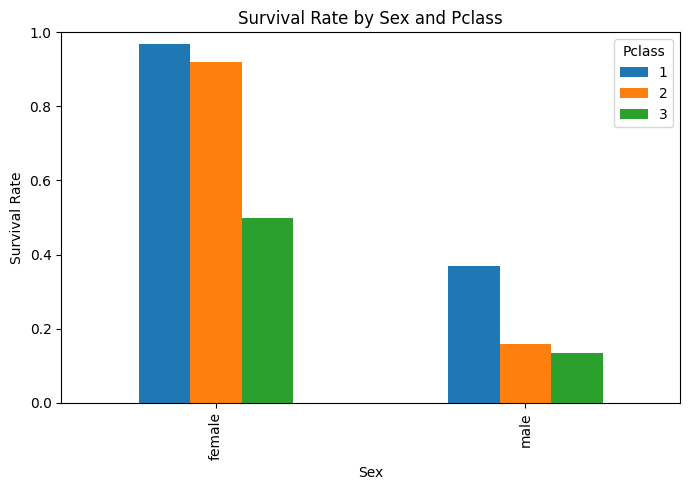

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
pivot_sex_pclass.plot(kind='bar', ax=ax)
ax.set_title('Survival Rate by Sex and Pclass')
ax.set_ylabel('Survival Rate')
ax.set_xlabel('Sex')
ax.set_ylim(0, 1)
ax.legend(title='Pclass')
plt.tight_layout()
plt.savefig('chart1_survival_by_sex_pclass.png', dpi=150)
plt.show()

#### 5-1. 시각화 (2) — 피벗 테이블 히트맵

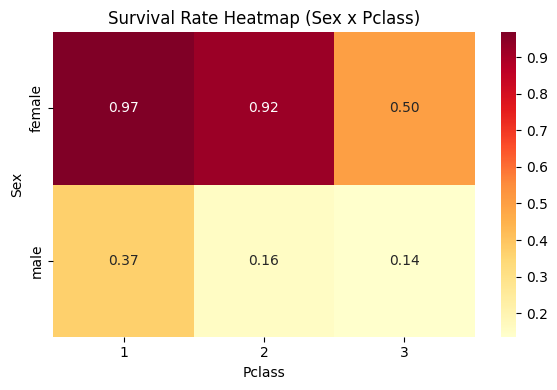

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_sex_pclass, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
ax.set_title('Survival Rate Heatmap (Sex x Pclass)')
plt.tight_layout()
plt.savefig('chart2_heatmap_sex_pclass.png', dpi=150)
plt.show()

#### 5-2. 시각화 (3) — 나이 분포 그래프

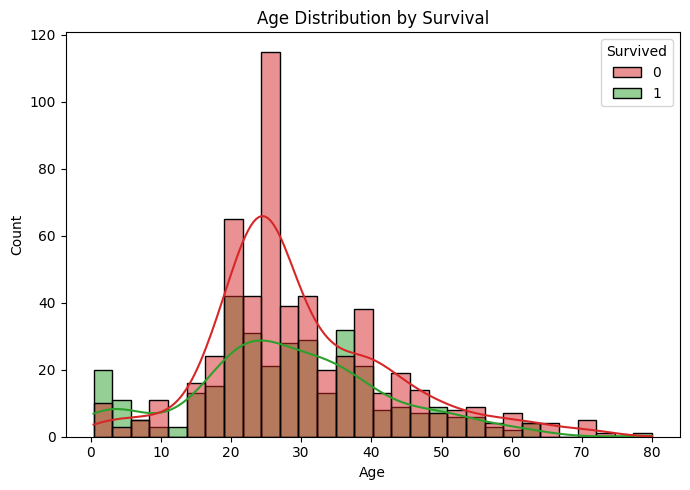

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             kde=True, palette=['#d62728', '#2ca02c'], ax=ax)
ax.set_title('Age Distribution by Survival')
plt.tight_layout()
plt.savefig('chart3_age_distribution.png', dpi=150)
plt.show()

#### 6. 인사이트 요약

In [ ]:
female_1st = pivot_sex_pclass.loc['female', 1]
male_3rd = pivot_sex_pclass.loc['male', 3]
overall_female = survival_by_sex['female']
overall_male = survival_by_sex['male']
cabin_diff = df.groupby('Has_Cabin')['Survived'].mean()

insights = f"""1. 여성 전체 생존율은 {overall_female:.0%}, 남성은 {overall_male:.0%}로 성별이 생존에 가장 큰 영향을 미쳤다.
2. 1등급 여성 승객 생존율은 {female_1st:.0%}에 달한 반면, 3등급 남성은 {male_3rd:.0%}에 그쳐 성별과 좌석등급이 결합될수록 격차가 극대화됐다.
3. 좌석 등급이 높을수록(1등급>2등급>3등급) 생존율이 뚜렷하게 감소했다({survival_by_pclass['mean'][1]:.0%} > {survival_by_pclass['mean'][2]:.0%} > {survival_by_pclass['mean'][3]:.0%}).
4. 객실(Cabin) 기록이 있는 승객의 생존율({cabin_diff[1]:.0%})이 없는 승객({cabin_diff[0]:.0%})보다 높아, 이는 상위 등급/높은 요금 승객군을 간접적으로 반영한다.
5. 나이 분포상 유아·어린이 생존율이 비교적 높게 나타나 '여성과 아이 우선' 탈출 관행이 데이터에도 반영되어 있다."""

print(insights)

1. 여성 전체 생존율은 74%, 남성은 19%로 성별이 생존에 가장 큰 영향을 미쳤다.
2. 1등급 여성 승객 생존율은 97%에 달한 반면, 3등급 남성은 14%에 그쳐 성별과 좌석등급이 결합될수록 격차가 극대화됐다.
3. 좌석 등급이 높을수록(1등급>2등급>3등급) 생존율이 뚜렷하게 감소했다(63% > 47% > 24%).
4. 객실(Cabin) 기록이 있는 승객의 생존율(67%)이 없는 승객(30%)보다 높아, 이는 상위 등급/높은 요금 승객군을 간접적으로 반영한다.
5. 나이 분포상 유아·어린이 생존율이 비교적 높게 나타나 '여성과 아이 우선' 탈출 관행이 데이터에도 반영되어 있다.
